In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

In [9]:
d = pd.read_csv('../data/clean_house_data.csv')
d.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056



Linear Regression Results:
RMSE: $269,566.87
MAE: $233,363.90
R2 Score: 0.0102
Cross-val R2: -0.0114 (+/- 0.0256)

Ridge Results:
RMSE: $269,568.32
MAE: $233,364.63
R2 Score: 0.0102
Cross-val R2: -0.0113 (+/- 0.0256)

Lasso Results:
RMSE: $269,566.84
MAE: $233,363.78
R2 Score: 0.0102
Cross-val R2: -0.0114 (+/- 0.0256)

ElasticNet Results:
RMSE: $270,240.69
MAE: $233,822.73
R2 Score: 0.0052
Cross-val R2: -0.0063 (+/- 0.0129)


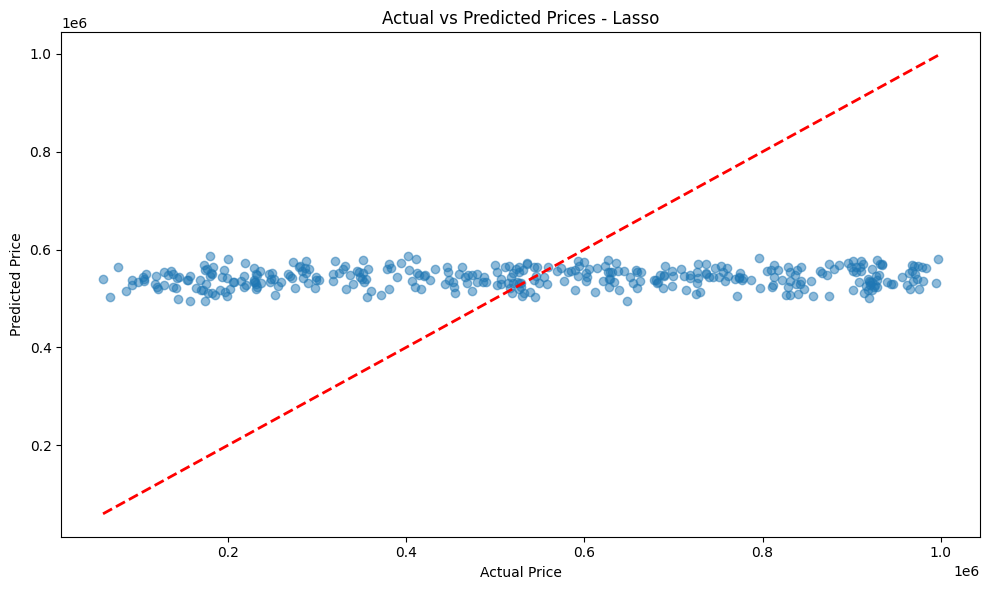

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# Load and prepare data
df = pd.read_csv('../data/clean_house_data.csv')
X = df.drop(['Price', 'Id'], axis=1)
y = df['Price']

# Split numerical and categorical columns
numerical_features = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']
categorical_features = ['Location', 'Condition', 'Garage']

# Create preprocessing pipelines
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first', sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create models dictionary
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=1.0),
    'ElasticNet': ElasticNet(alpha=1.0, l1_ratio=0.5)
}

# Results dictionary
results = {}

# Train and evaluate each model
for name, model in models.items():
    # Create pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # Train model
    pipeline.fit(X_train, y_train)
    
    # Make predictions
    y_pred = pipeline.predict(X_test)
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Perform cross-validation
    cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='r2')
    
    # Store results
    results[name] = {
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'CV_R2_mean': cv_scores.mean(),
        'CV_R2_std': cv_scores.std()
    }

# Print results
for model_name, metrics in results.items():
    print(f"\n{model_name} Results:")
    print(f"RMSE: ${metrics['RMSE']:,.2f}")
    print(f"MAE: ${metrics['MAE']:,.2f}")
    print(f"R2 Score: {metrics['R2']:.4f}")
    print(f"Cross-val R2: {metrics['CV_R2_mean']:.4f} (+/- {metrics['CV_R2_std']*2:.4f})")

# Visualize actual vs predicted for best model
best_model = max(results.items(), key=lambda x: x[1]['R2'])[0]
best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', models[best_model])
])
best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Actual vs Predicted Prices - {best_model}')
plt.tight_layout()
plt.show()


Training Decision Tree...

Training Random Forest...

Training Gradient Boosting...

Training SVR...

Decision Tree Results:
RMSE: $273,237.47
MAE: $236,268.03
R2 Score: -0.0170
Best CV R2: -0.0690
Best Parameters: {'regressor__max_depth': 5, 'regressor__min_samples_split': 10}

Random Forest Results:
RMSE: $275,813.98
MAE: $238,686.38
R2 Score: -0.0362
Best CV R2: -0.0386
Best Parameters: {'regressor__max_depth': 10, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200}

Gradient Boosting Results:
RMSE: $272,265.33
MAE: $235,023.30
R2 Score: -0.0097
Best CV R2: -0.0052
Best Parameters: {'regressor__learning_rate': 0.01, 'regressor__max_depth': 3, 'regressor__n_estimators': 100}

SVR Results:
RMSE: $270,954.15
MAE: $234,448.81
R2 Score: -0.0000
Best CV R2: -0.0026
Best Parameters: {'regressor__C': 10, 'regressor__kernel': 'rbf'}


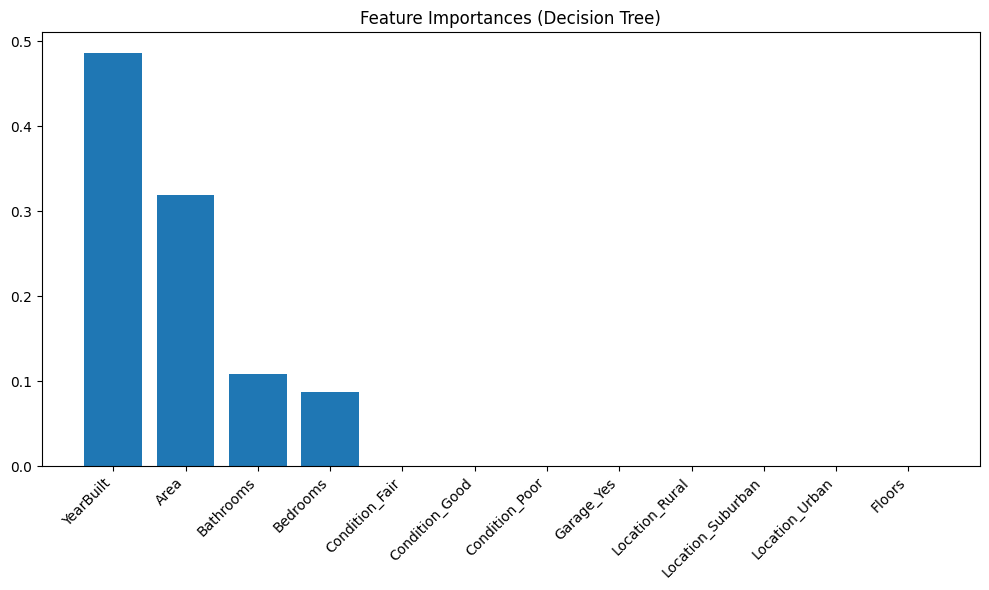

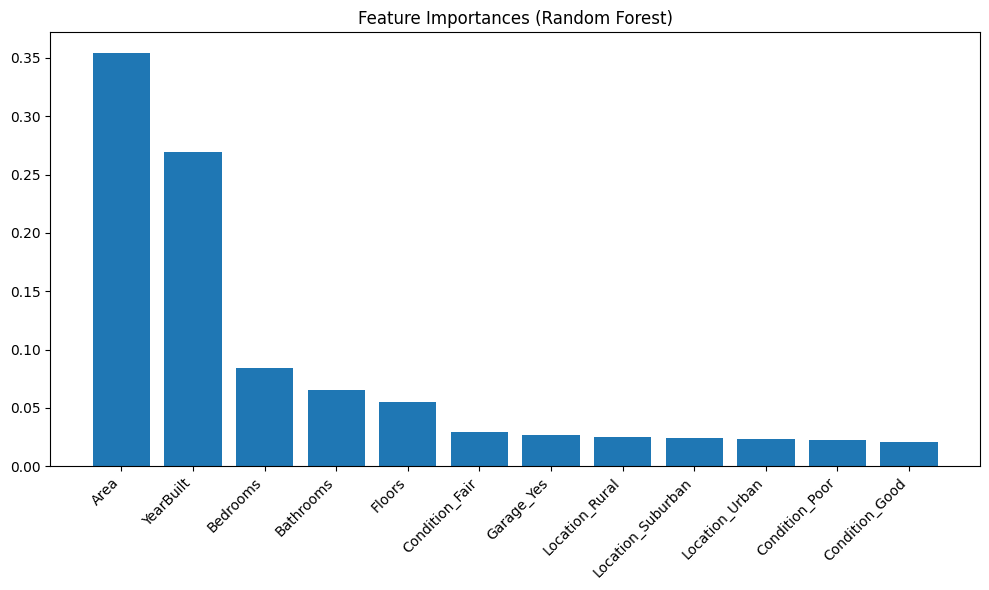

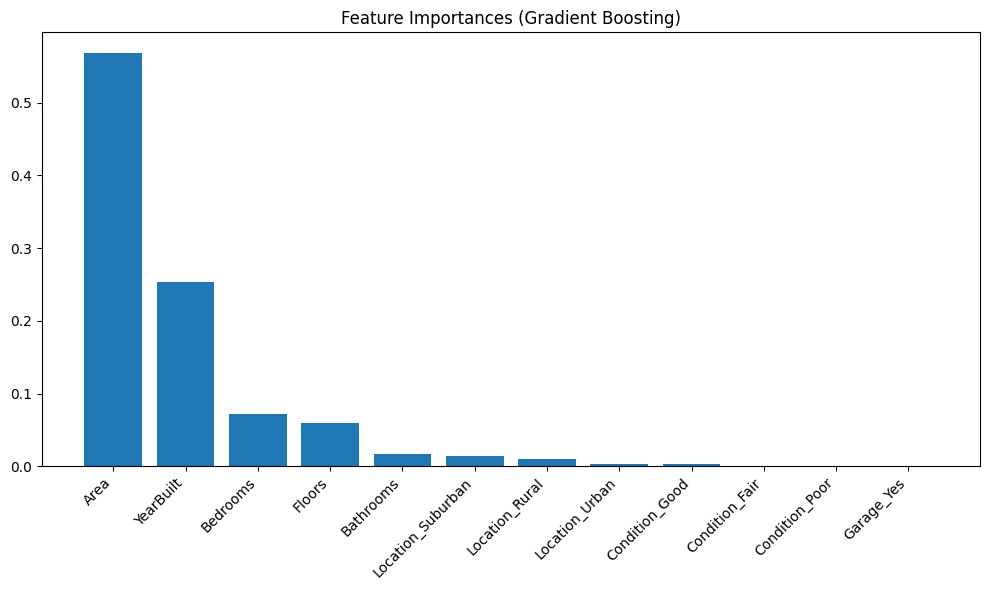

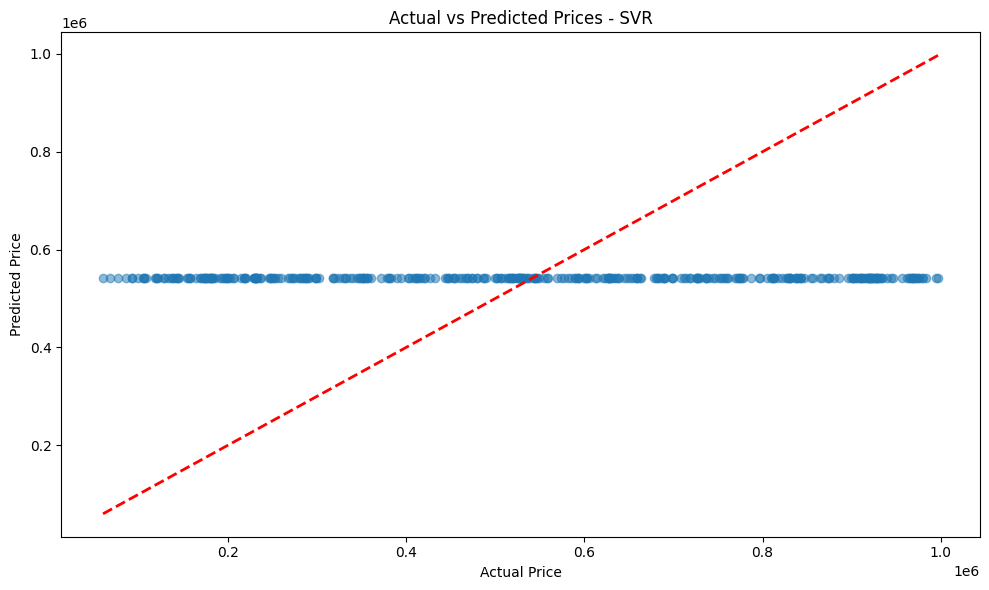

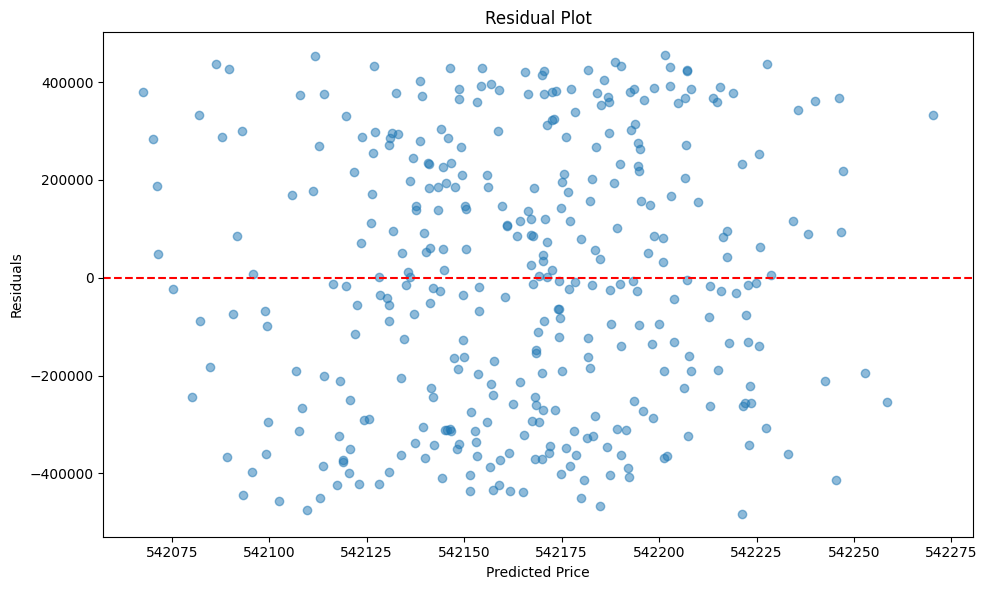

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# Load and prepare data
df = pd.read_csv('../data/clean_house_data.csv')
X = df.drop(['Price', 'Id'], axis=1)
y = df['Price']

# Split features
numerical_features = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']
categorical_features = ['Location', 'Condition', 'Garage']

# Preprocessing
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first', sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define models with initial hyperparameters
models = {
    'Decision Tree': {
        'model': DecisionTreeRegressor(random_state=42),
        'params': {
            'regressor__max_depth': [5, 10, 15],
            'regressor__min_samples_split': [2, 5, 10]
        }
    },
    'Random Forest': {
        'model': RandomForestRegressor(random_state=42),
        'params': {
            'regressor__n_estimators': [100, 200],
            'regressor__max_depth': [10, 20],
            'regressor__min_samples_split': [2, 5]
        }
    },
    'Gradient Boosting': {
        'model': GradientBoostingRegressor(random_state=42),
        'params': {
            'regressor__n_estimators': [100, 200],
            'regressor__learning_rate': [0.01, 0.1],
            'regressor__max_depth': [3, 5]
        }
    },
    'SVR': {
        'model': SVR(),
        'params': {
            'regressor__kernel': ['rbf', 'linear'],
            'regressor__C': [0.1, 1, 10]
        }
    }
}

# Results dictionary
results = {}
best_models = {}

# Train and evaluate each model
for name, model_info in models.items():
    print(f"\nTraining {name}...")
    
    # Create pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model_info['model'])
    ])
    
    # Perform GridSearch
    grid_search = GridSearchCV(
        pipeline,
        model_info['params'],
        cv=5,
        scoring='r2',
        n_jobs=-1
    )
    
    # Fit and time the model
    grid_search.fit(X_train, y_train)
    
    # Get best model
    best_models[name] = grid_search.best_estimator_
    y_pred = grid_search.predict(X_test)
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Store results
    results[name] = {
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'Best Params': grid_search.best_params_,
        'Best CV Score': grid_search.best_score_
    }

# Print results
for model_name, metrics in results.items():
    print(f"\n{model_name} Results:")
    print(f"RMSE: ${metrics['RMSE']:,.2f}")
    print(f"MAE: ${metrics['MAE']:,.2f}")
    print(f"R2 Score: {metrics['R2']:.4f}")
    print(f"Best CV R2: {metrics['Best CV Score']:.4f}")
    print("Best Parameters:", metrics['Best Params'])

# Feature importance for tree-based models
def plot_feature_importance(model_name, model):
    if hasattr(model.named_steps['regressor'], 'feature_importances_'):
        # Get feature names after preprocessing
        cat_features = (model.named_steps['preprocessor']
                       .named_transformers_['cat']
                       .get_feature_names_out(categorical_features))
        feature_names = numerical_features + list(cat_features)
        
        # Get feature importances
        importances = model.named_steps['regressor'].feature_importances_
        
        # Sort features by importance
        indices = np.argsort(importances)[::-1]
        
        # Plot
        plt.figure(figsize=(10, 6))
        plt.title(f'Feature Importances ({model_name})')
        plt.bar(range(len(importances)), importances[indices])
        plt.xticks(range(len(importances)), 
                  [feature_names[i] for i in indices], 
                  rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

# Plot feature importance for tree-based models
for name, model in best_models.items():
    if name in ['Decision Tree', 'Random Forest', 'Gradient Boosting']:
        plot_feature_importance(name, model)

# Plot actual vs predicted for best model
best_model_name = max(results.items(), key=lambda x: x[1]['R2'])[0]
best_model = best_models[best_model_name]
y_pred = best_model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Actual vs Predicted Prices - {best_model_name}')
plt.tight_layout()
plt.show()

# Plot residuals
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()


Training Random Forest...

Training Gradient Boosting...

Random Forest Results:
RMSE: $295,578.65
MAE: $251,346.19
R2 Score: -0.1901
Best CV R2: -0.1029
Best Parameters: {'regressor__max_depth': 15, 'regressor__max_features': 'log2', 'regressor__min_samples_split': 5, 'regressor__n_estimators': 300}

Gradient Boosting Results:
RMSE: $299,239.28
MAE: $251,911.48
R2 Score: -0.2197
Best CV R2: -0.1749
Best Parameters: {'regressor__learning_rate': 0.05, 'regressor__max_depth': 5, 'regressor__n_estimators': 200, 'regressor__subsample': 0.8}


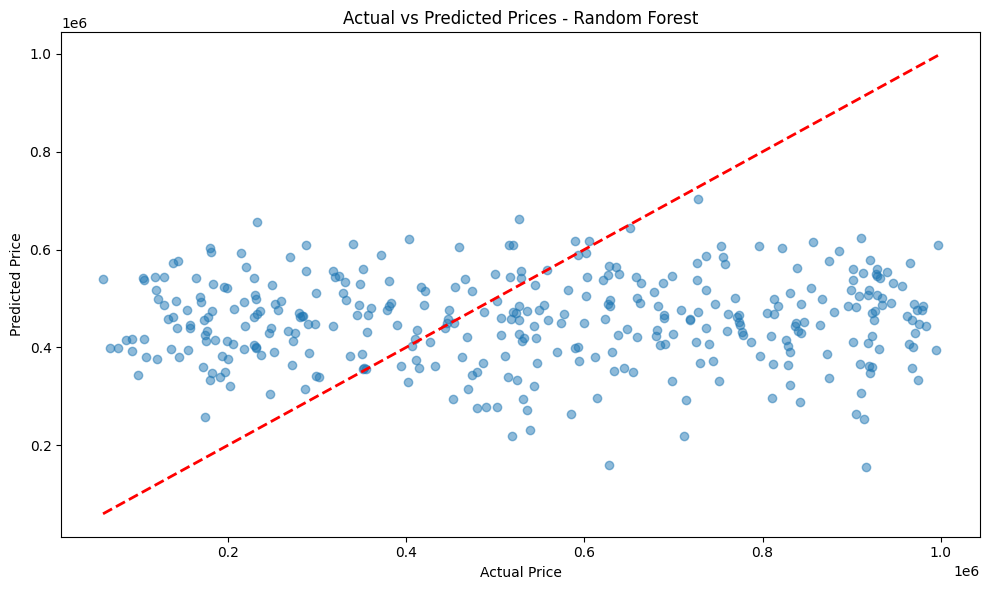

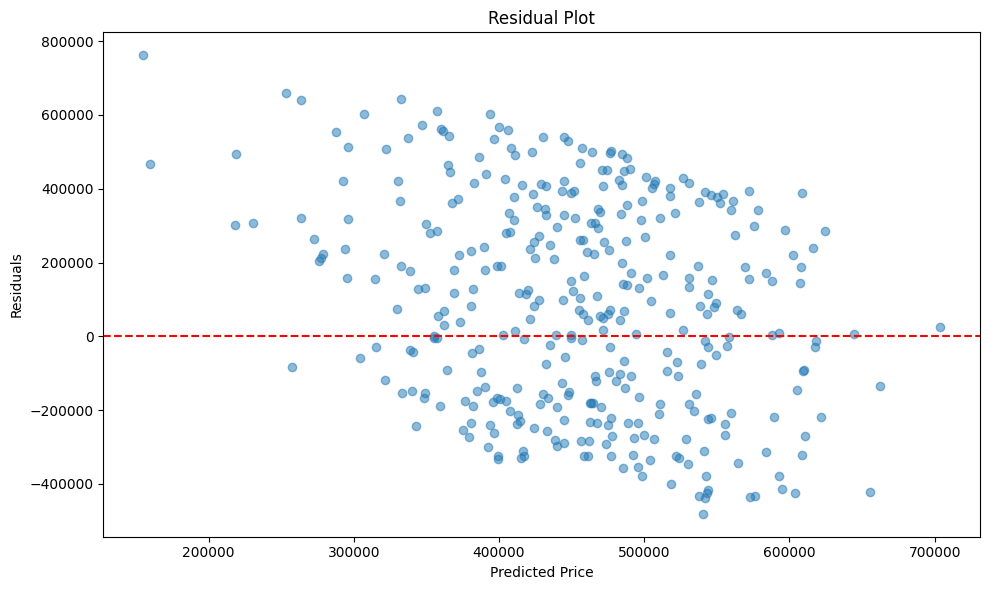

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Load data
df = pd.read_csv('../data/clean_house_data.csv')
X = df.drop(['Price', 'Id'], axis=1)
y = df['Price']

# Log transform target
y = np.log1p(y)

# Split features
numerical_features = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']
categorical_features = ['Location', 'Condition', 'Garage']

# Create interaction features
def create_interactions(df, num_features):
    interactions = pd.DataFrame()
    for i in range(len(num_features)):
        for j in range(i+1, len(num_features)):
            feature_name = f'{num_features[i]}_{num_features[j]}_interaction'
            interactions[feature_name] = df[num_features[i]] * df[num_features[j]]
    return interactions

X = pd.concat([X, create_interactions(X, numerical_features)], axis=1)

# Update numerical features list
interaction_features = [col for col in X.columns if 'interaction' in col]
numerical_features = numerical_features + interaction_features

# Preprocessing
numeric_transformer = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False))
])

categorical_transformer = OneHotEncoder(drop='first', sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models with updated parameters
models = {
    'Random Forest': {
        'model': RandomForestRegressor(random_state=42),
        'params': {
            'regressor__n_estimators': [200, 300],
            'regressor__max_depth': [15, 20],
            'regressor__min_samples_split': [2, 5],
            'regressor__max_features': ['sqrt', 'log2']
        }
    },
    'Gradient Boosting': {
        'model': GradientBoostingRegressor(random_state=42),
        'params': {
            'regressor__n_estimators': [200, 300],
            'regressor__learning_rate': [0.05, 0.1],
            'regressor__max_depth': [5, 7],
            'regressor__subsample': [0.8, 1.0]
        }
    }
}

results = {}
best_models = {}

# Train and evaluate
for name, model_info in models.items():
    print(f"\nTraining {name}...")
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model_info['model'])
    ])
    
    grid_search = GridSearchCV(
        pipeline,
        model_info['params'],
        cv=5,
        scoring='r2',
        n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train)
    best_models[name] = grid_search.best_estimator_
    y_pred = grid_search.predict(X_test)
    
    # Transform predictions back to original scale
    y_pred_orig = np.expm1(y_pred)
    y_test_orig = np.expm1(y_test)
    
    # Calculate metrics
    mse = mean_squared_error(y_test_orig, y_pred_orig)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_orig, y_pred_orig)
    r2 = r2_score(y_test_orig, y_pred_orig)
    
    results[name] = {
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'Best Params': grid_search.best_params_,
        'Best CV Score': grid_search.best_score_
    }

# Print results
for model_name, metrics in results.items():
    print(f"\n{model_name} Results:")
    print(f"RMSE: ${metrics['RMSE']:,.2f}")
    print(f"MAE: ${metrics['MAE']:,.2f}")
    print(f"R2 Score: {metrics['R2']:.4f}")
    print(f"Best CV R2: {metrics['Best CV Score']:.4f}")
    print("Best Parameters:", metrics['Best Params'])

# Plot actual vs predicted for best model
best_model_name = max(results.items(), key=lambda x: x[1]['R2'])[0]
best_model = best_models[best_model_name]
y_pred = best_model.predict(X_test)
y_pred_orig = np.expm1(y_pred)
y_test_orig = np.expm1(y_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test_orig, y_pred_orig, alpha=0.5)
plt.plot([y_test_orig.min(), y_test_orig.max()], 
         [y_test_orig.min(), y_test_orig.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Actual vs Predicted Prices - {best_model_name}')
plt.tight_layout()
plt.show()

# Plot residuals
residuals = y_test_orig - y_pred_orig
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_orig, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

In [14]:
def format_currency(value):
    """Format large numbers as currency with M/K suffix"""
    if value >= 1000000:
        return f"${value/1000000:.2f}M"
    elif value >= 1000:
        return f"${value/1000:.1f}K"
    else:
        return f"${value:.2f}"

def analyze_house_data(df):
    print("="*50)
    print("HOUSE PRICE DATASET ANALYSIS REPORT")
    print("="*50)
    
    # 1. Basic Dataset Information
    print("\n1. DATASET OVERVIEW")
    print("-"*30)
    print(f"Total number of properties: {len(df):,}")
    print(f"Number of features: {len(df.columns)}")
    print("\nFeatures in dataset:")
    for col in df.columns:
        print(f"- {col}: {df[col].dtype}")
    
    # 2. Price Analysis
    print("\n2. PRICE ANALYSIS")
    print("-"*30)
    price_stats = df['Price'].describe()
    print(f"Price Range: {format_currency(price_stats['min'])} to {format_currency(price_stats['max'])}")
    print(f"Mean Price: {format_currency(price_stats['mean'])}")
    print(f"Median Price: {format_currency(price_stats['50%'])}")
    print(f"Price Standard Deviation: {format_currency(price_stats['std'])}")
    
    # Calculate price quartiles
    q1, q3 = df['Price'].quantile([0.25, 0.75])
    print(f"\nPrice Quartiles:")
    print(f"- 25th percentile: {format_currency(q1)}")
    print(f"- 75th percentile: {format_currency(q3)}")
    
    # 3. Location Analysis
    print("\n3. LOCATION ANALYSIS")
    print("-"*30)
    location_stats = df.groupby('Location').agg({
        'Price': ['count', 'mean', 'median', 'std']
    })
    
    print("Price statistics by location:")
    for location in location_stats.index:
        stats = location_stats.loc[location, 'Price']
        print(f"\n{location}:")
        print(f"- Number of properties: {stats['count']:,}")
        print(f"- Average price: {format_currency(stats['mean'])}")
        print(f"- Median price: {format_currency(stats['median'])}")
        print(f"- Price std dev: {format_currency(stats['std'])}")
    
    # 4. Property Characteristics
    print("\n4. PROPERTY CHARACTERISTICS")
    print("-"*30)
    print("\nBedrooms:")
    bedroom_stats = df['Bedrooms'].value_counts().sort_index()
    for beds, count in bedroom_stats.items():
        percentage = (count/len(df))*100
        print(f"- {beds} bedrooms: {count:,} properties ({percentage:.1f}%)")
        
    print("\nBathrooms:")
    bathroom_stats = df['Bathrooms'].value_counts().sort_index()
    for baths, count in bathroom_stats.items():
        percentage = (count/len(df))*100
        print(f"- {baths} bathrooms: {count:,} properties ({percentage:.1f}%)")
    
    # 5. Property Condition Analysis
    print("\n5. CONDITION ANALYSIS")
    print("-"*30)
    condition_stats = df.groupby('Condition').agg({
        'Price': ['count', 'mean', 'median'],
        'YearBuilt': 'mean'
    }).round(0)
    
    for condition in condition_stats.index:
        price_stats = condition_stats.loc[condition, 'Price']
        year_built = condition_stats.loc[condition, 'YearBuilt']
        print(f"\n{condition} Condition Properties:")
        print(f"- Count: {int(price_stats['count']):,}")
        print(f"- Average price: {format_currency(price_stats['mean'])}")
        print(f"- Median price: {format_currency(price_stats['median'])}")
        print(f"- Average year built: {int(year_built)}")
    
    # 6. Age and Price Relationship
    print("\n6. AGE AND PRICE RELATIONSHIP")
    print("-"*30)
    df['Age'] = 2024 - df['YearBuilt']
    age_correlation = df['Age'].corr(df['Price'])
    print(f"Correlation between age and price: {age_correlation:.3f}")
    
    # Group properties by decades
    df['Decade'] = (df['YearBuilt'] // 10) * 10
    decade_stats = df.groupby('Decade').agg({
        'Price': ['count', 'mean'],
        'YearBuilt': 'count'
    }).sort_index()
    
    print("\nPrice by construction decade:")
    for decade in decade_stats.index:
        stats = decade_stats.loc[decade]
        print(f"\n{decade}s:")
        print(f"- Number of properties: {int(stats['YearBuilt']):,}")
        print(f"- Average price: {format_currency(stats['Price']['mean'])}")
    
    # 7. Price per Square Foot Analysis
    print("\n7. PRICE PER SQUARE FOOT ANALYSIS")
    print("-"*30)
    df['Price_per_sqft'] = df['Price'] / df['Area']
    ppsf_stats = df['Price_per_sqft'].describe()
    
    print(f"Average price per sq ft: ${ppsf_stats['mean']:.2f}")
    print(f"Median price per sq ft: ${ppsf_stats['50%']:.2f}")
    print(f"Price per sq ft range: ${ppsf_stats['min']:.2f} to ${ppsf_stats['max']:.2f}")
    
    # 8. Key Insights
    print("\n8. KEY INSIGHTS")
    print("-"*30)
    print(f"1. Most expensive location: {df.groupby('Location')['Price'].mean().idxmax()}")
    print(f"2. Most common number of bedrooms: {int(df['Bedrooms'].mode().values[0])}")
    print(f"3. Average house age: {df['Age'].mean():.1f} years")
    print(f"4. Property with highest price per sq ft: ${df['Price_per_sqft'].max():.2f}/sq ft")
    print(f"5. Most common condition: {df['Condition'].mode().values[0]}")
    
    # 9. Correlation Analysis
    print("\n9. CORRELATION ANALYSIS")
    print("-"*30)
    numerical_cols = ['Price', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']
    correlation_matrix = df[numerical_cols].corr()['Price'].sort_values(ascending=False)
    print("Correlation with Price:")
    for feature, corr in correlation_matrix.items():
        if feature != 'Price':
            print(f"- {feature}: {corr:.3f}")

# Run the analysis
analyze_house_data(d)

HOUSE PRICE DATASET ANALYSIS REPORT

1. DATASET OVERVIEW
------------------------------
Total number of properties: 1,800
Number of features: 10

Features in dataset:
- Id: int64
- Area: int64
- Bedrooms: int64
- Bathrooms: int64
- Floors: int64
- YearBuilt: int64
- Location: object
- Condition: object
- Garage: object
- Price: int64

2. PRICE ANALYSIS
------------------------------
Price Range: $59.0K to $997.2K
Mean Price: $541.6K
Median Price: $540.4K
Price Standard Deviation: $261.1K

Price Quartiles:
- 25th percentile: $320.6K
- 75th percentile: $765.9K

3. LOCATION ANALYSIS
------------------------------
Price statistics by location:

Downtown:
- Number of properties: 495.0
- Average price: $544.3K
- Median price: $540.3K
- Price std dev: $257.0K

Rural:
- Number of properties: 431.0
- Average price: $538.3K
- Median price: $527.0K
- Price std dev: $263.0K

Suburban:
- Number of properties: 441.0
- Average price: $558.2K
- Median price: $589.2K
- Price std dev: $253.9K

Urban:
- 

C:\Users\User\AppData\Local\Temp\ipykernel_13984\4143863613.py:85: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"- Average year built: {int(year_built)}")
C:\Users\User\AppData\Local\Temp\ipykernel_13984\4143863613.py:105: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"- Number of properties: {int(stats['YearBuilt']):,}")


Classification Report:
                           precision    recall  f1-score   support

       High ($765K-$997K)       0.29      0.28      0.28        94
         Low ($59K-$320K)       0.24      0.20      0.22       101
Medium-High ($540K-$765K)       0.23      0.27      0.25        83
 Medium-Low ($320K-$540K)       0.24      0.27      0.26        82

                 accuracy                           0.25       360
                macro avg       0.25      0.25      0.25       360
             weighted avg       0.25      0.25      0.25       360



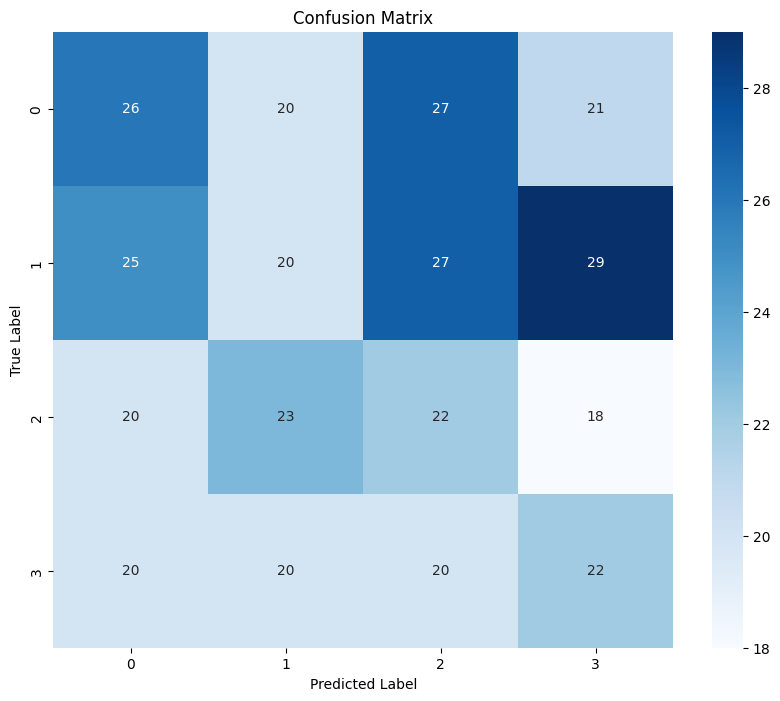

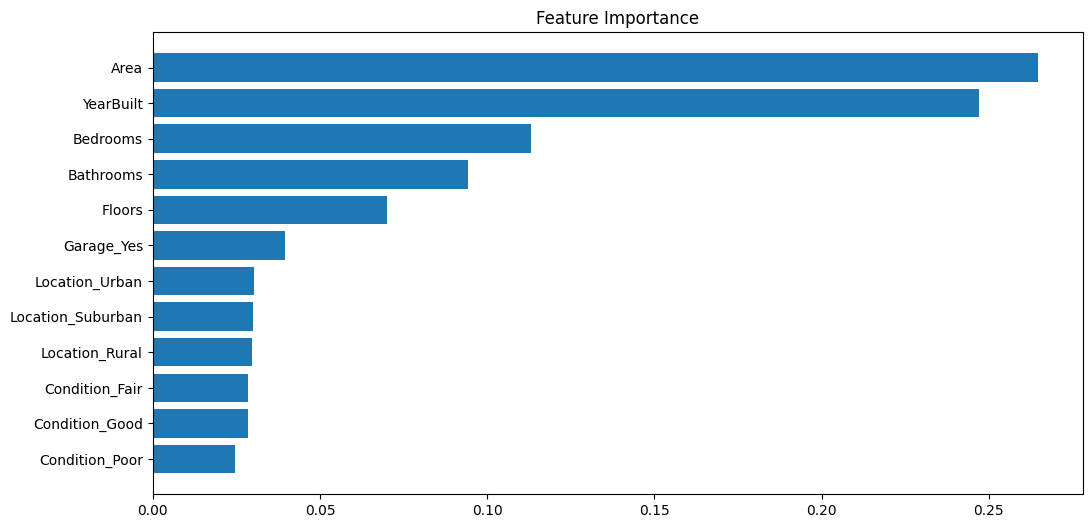

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('../data/clean_house_data.csv')

# Create price buckets
df['price_category'] = pd.qcut(df['Price'], q=4, labels=['Low ($59K-$320K)', 'Medium-Low ($320K-$540K)', 'Medium-High ($540K-$765K)', 'High ($765K-$997K)'])

# Prepare features and target
X = df.drop(['Price', 'Id', 'price_category'], axis=1)
y = df['price_category']

# Split features
numerical_features = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']
categorical_features = ['Location', 'Condition', 'Garage']

# Preprocessing
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train model
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=300, max_depth=None, random_state=42))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Print results
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Feature importance
feature_names = (numerical_features + 
                model.named_steps['preprocessor']
                .named_transformers_['cat']
                .get_feature_names_out(categorical_features).tolist())

importances = model.named_steps['classifier'].feature_importances_
sorted_idx = np.argsort(importances)
pos = np.arange(sorted_idx.shape[0]) + .5

plt.figure(figsize=(12, 6))
plt.barh(pos, importances[sorted_idx])
plt.yticks(pos, np.array(feature_names)[sorted_idx])
plt.title('Feature Importance')
plt.show()


Random Forest Results:

Classification Report:
                           precision    recall  f1-score   support

Category 0 ($-infK-$378K)       0.26      0.17      0.20       120
 Category 1 ($378K-$683K)       0.31      0.42      0.35       114
 Category 2 ($683K-$997K)       0.37      0.37      0.37       126

                 accuracy                           0.32       360
                macro avg       0.31      0.32      0.31       360
             weighted avg       0.31      0.32      0.31       360



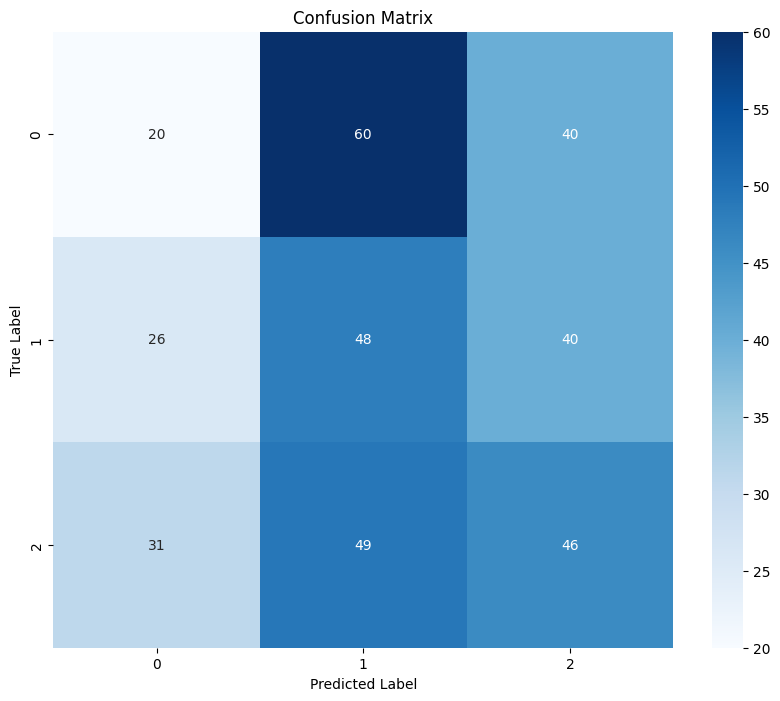


Gradient Boosting Results:

Classification Report:
                           precision    recall  f1-score   support

Category 0 ($-infK-$378K)       0.26      0.21      0.23       120
 Category 1 ($378K-$683K)       0.25      0.27      0.26       114
 Category 2 ($683K-$997K)       0.36      0.40      0.38       126

                 accuracy                           0.30       360
                macro avg       0.29      0.30      0.29       360
             weighted avg       0.29      0.30      0.29       360



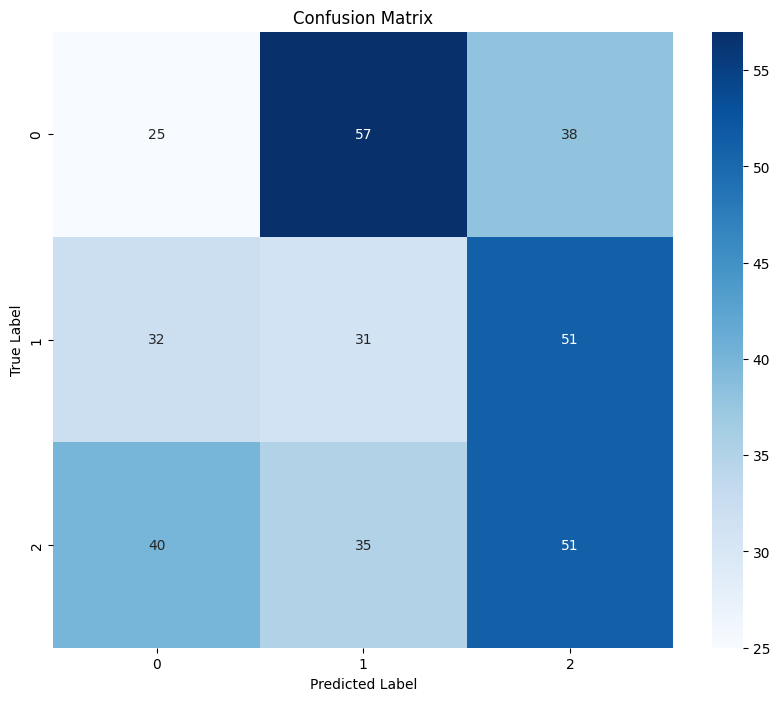

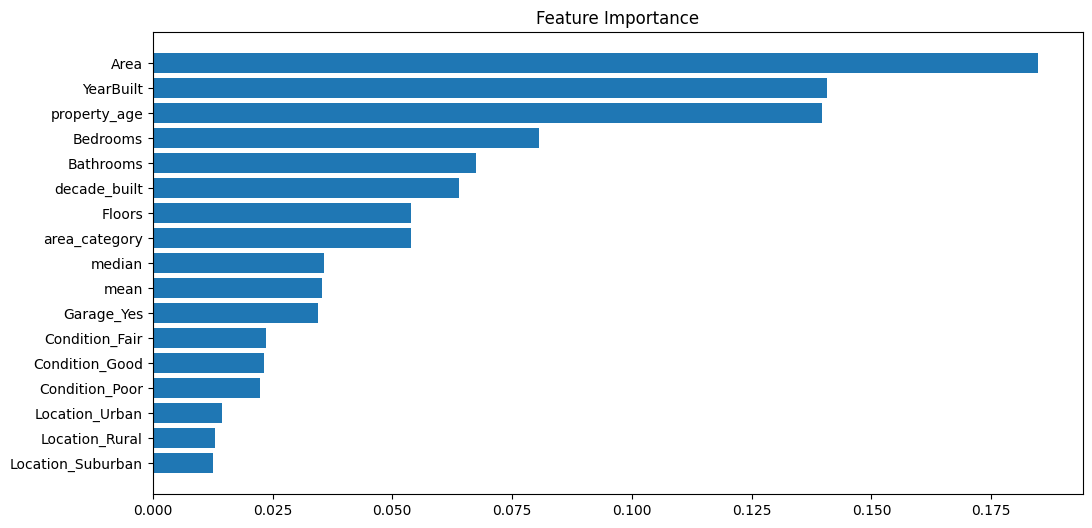

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, KBinsDiscretizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

def create_features(df):
    """Create additional features from existing data"""
    # Create copy to avoid modifying original
    df = df.copy()
    
    # Add property age
    current_year = datetime.now().year
    df['property_age'] = current_year - df['YearBuilt']
    
    # Add price per square foot (before dropping price for training)
    df['price_per_sqft'] = df['Price'] / df['Area']
    
    # Create decade built
    df['decade_built'] = (df['YearBuilt'] // 10) * 10
    
    # Create area bins
    area_discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
    df['area_category'] = area_discretizer.fit_transform(df[['Area']])
    
    # Create location-based features
    location_stats = df.groupby('Location')['price_per_sqft'].agg(['mean', 'median']).reset_index()
    df = df.merge(location_stats, on='Location', suffixes=('', '_location'))
    
    return df

def create_price_categories(df, n_categories=3, strategy='kmeans'):
    """Create price categories using different strategies"""
    if strategy == 'kmeans':
        discretizer = KBinsDiscretizer(n_bins=n_categories, encode='ordinal', strategy='kmeans')
        df['price_category'] = discretizer.fit_transform(df[['Price']])
        
        # Create labels with price ranges
        bins = np.concatenate([[-np.inf], discretizer.bin_edges_[0][1:], [np.inf]])
        labels = [f'Category {i} (${bins[i]/1000:.0f}K-${bins[i+1]/1000:.0f}K)' 
                 for i in range(len(bins)-1)]
        df['price_category'] = pd.cut(df['Price'], bins=bins, labels=labels)
    else:
        df['price_category'] = pd.qcut(df['Price'], q=n_categories)
    
    return df

def train_evaluate_model(X_train, X_test, y_train, y_test, preprocessor, classifier):
    """Train model and print evaluation metrics"""
    # Create and train pipeline
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', classifier)
    ])
    
    # Fit model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Print results
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    return model

# Load and prepare data
df = pd.read_csv('../data/clean_house_data.csv')

# Create enhanced feature set
df = create_features(df)

# Create price categories (trying 3 categories with kmeans strategy)
df = create_price_categories(df, n_categories=3, strategy='kmeans')

# Prepare features and target
X = df.drop(['Price', 'Id', 'price_category', 'price_per_sqft'], axis=1)
y = df['price_category']

# Split features
numerical_features = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 
                     'property_age', 'decade_built', 'area_category',
                     'mean', 'median']
categorical_features = ['Location', 'Condition', 'Garage']

# Create preprocessor
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Try both Random Forest and Gradient Boosting
rf_classifier = RandomForestClassifier(n_estimators=300, max_depth=None, 
                                     min_samples_split=5, min_samples_leaf=2,
                                     random_state=42)

gb_classifier = GradientBoostingClassifier(n_estimators=300, learning_rate=0.1,
                                         max_depth=5, random_state=42)

# Train and evaluate Random Forest
print("\nRandom Forest Results:")
rf_model = train_evaluate_model(X_train, X_test, y_train, y_test, 
                              preprocessor, rf_classifier)

# Train and evaluate Gradient Boosting
print("\nGradient Boosting Results:")
gb_model = train_evaluate_model(X_train, X_test, y_train, y_test, 
                              preprocessor, gb_classifier)

# Feature importance for best model (using Random Forest as example)
feature_names = (numerical_features + 
                rf_model.named_steps['preprocessor']
                .named_transformers_['cat']
                .get_feature_names_out(categorical_features).tolist())

importances = rf_model.named_steps['classifier'].feature_importances_
sorted_idx = np.argsort(importances)
pos = np.arange(sorted_idx.shape[0]) + .5

plt.figure(figsize=(12, 6))
plt.barh(pos, importances[sorted_idx])
plt.yticks(pos, np.array(feature_names)[sorted_idx])
plt.title('Feature Importance')
plt.show()

In [29]:
df = pd.read_csv('../data/clean_house_data.csv')
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


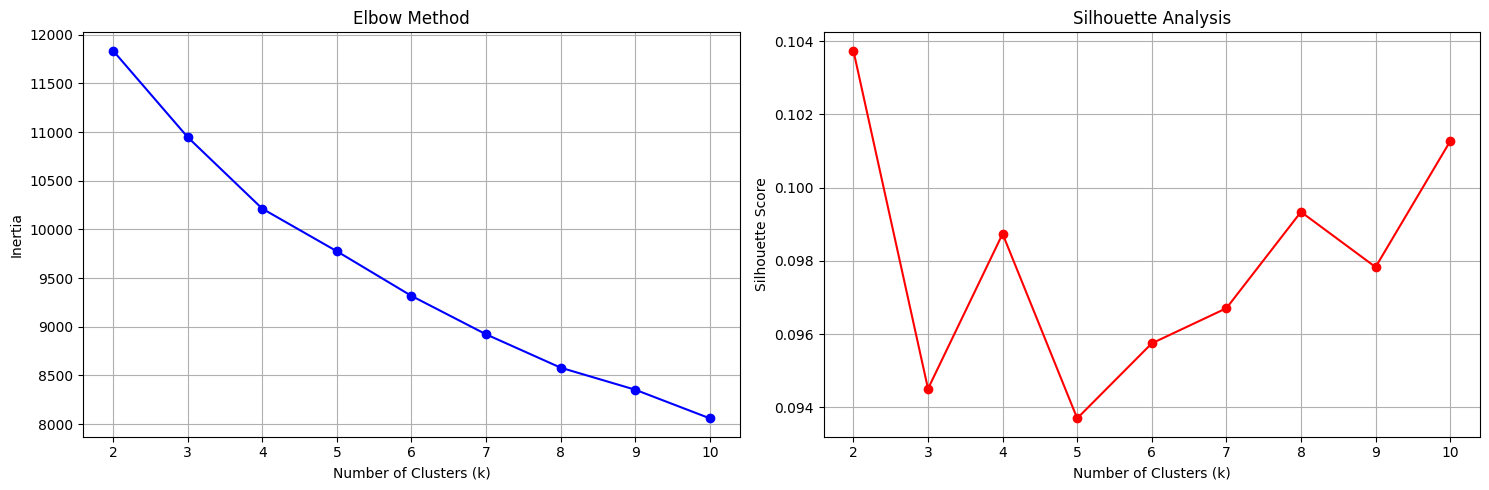


Silhouette Scores:
k=2: 0.104
k=3: 0.095
k=4: 0.099
k=5: 0.094
k=6: 0.096
k=7: 0.097
k=8: 0.099
k=9: 0.098
k=10: 0.101


In [35]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Load and preprocess
df = pd.read_csv('../data/clean_house_data.csv')
numerical_features = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price']
categorical_features = ['Location', 'Condition', 'Garage']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

X = preprocessor.fit_transform(df[numerical_features + categorical_features])

# Evaluate different k values
k_values = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))

# Plot elbow curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Elbow plot
ax1.plot(k_values, inertias, 'bo-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.grid(True)

# Silhouette score plot
ax2.plot(k_values, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis')
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\nSilhouette Scores:")
for k, score in zip(k_values, silhouette_scores):
    print(f"k={k}: {score:.3f}")


Cluster Sizes:
Cluster
0    944
1    856
Name: count, dtype: int64


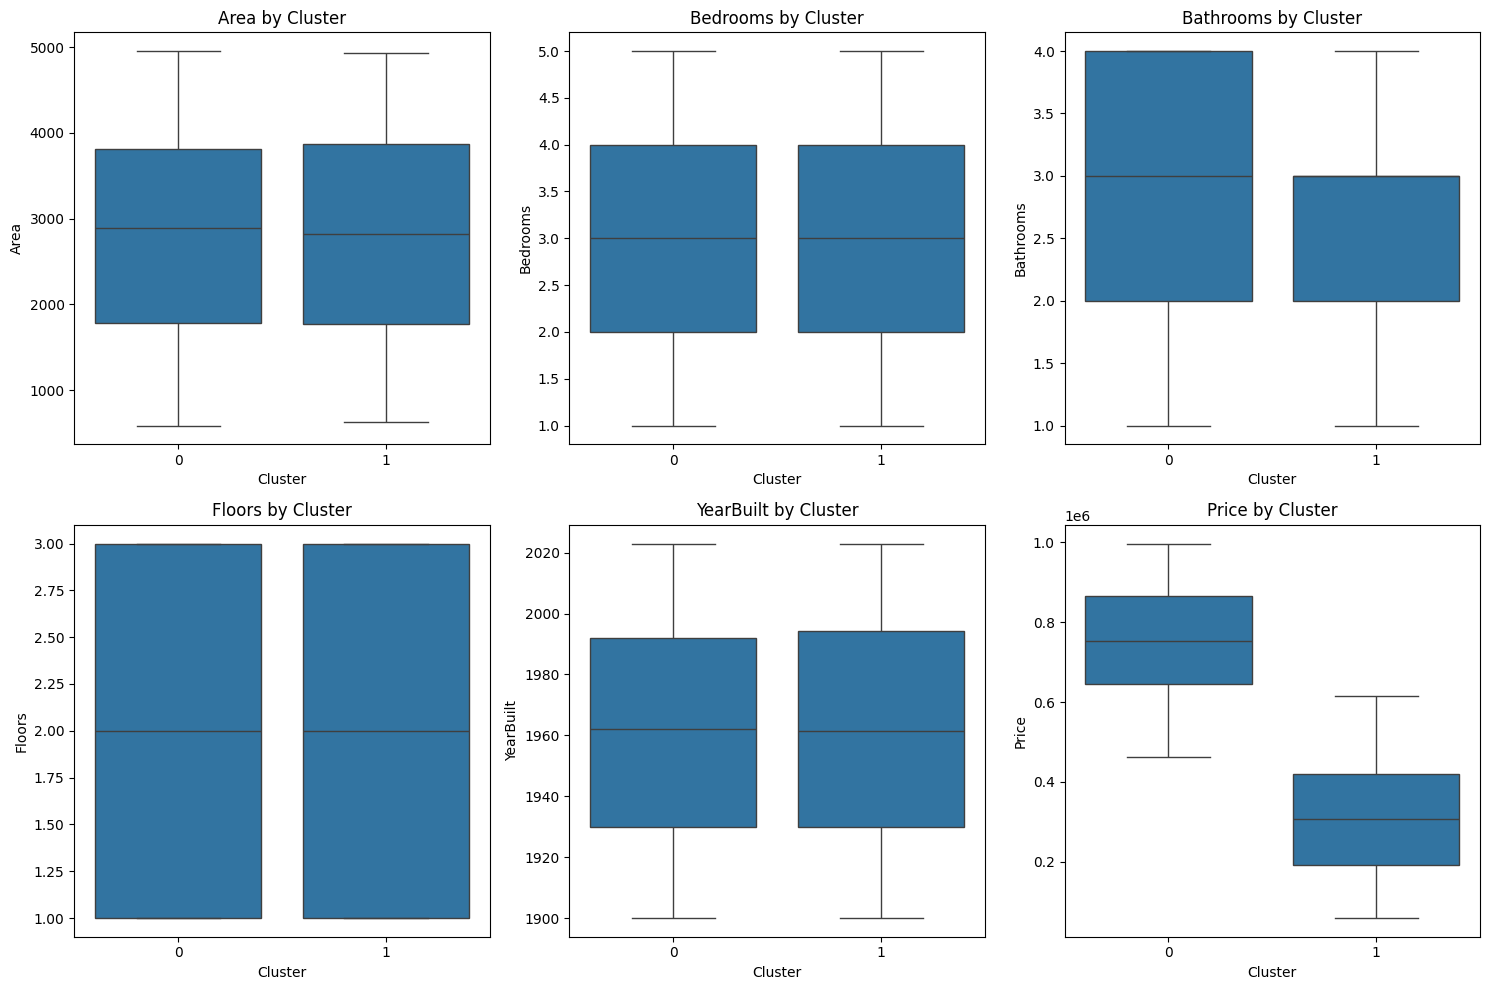


Categorical Features Distribution:

Location:
Location  Downtown  Rural  Suburban  Urban
Cluster                                   
0            0.271  0.235     0.263  0.231
1            0.279  0.244     0.225  0.251

Condition:
Condition  Excellent   Fair   Good   Poor
Cluster                                  
0              0.261  0.285  0.230  0.225
1              0.249  0.239  0.236  0.276

Garage:
Garage      No    Yes
Cluster              
0        0.530  0.470
1        0.507  0.493

Cluster Summary (Mean Values):
            Area  Bedrooms  Bathrooms  Floors  YearBuilt      Price
Cluster                                                            
0        2806.20      2.99       2.60    2.11    1961.67  753424.07
1        2829.83      3.06       2.52    1.86    1961.84  307956.51


In [36]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Load and preprocess
df = pd.read_csv('../data/clean_house_data.csv')
numerical_features = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price']
categorical_features = ['Location', 'Condition', 'Garage']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

X = preprocessor.fit_transform(df[numerical_features + categorical_features])

# PCA with 6 components
pca = PCA(n_components=6)
X_pca = pca.fit_transform(X)

# K-means with k=2
kmeans = KMeans(n_clusters=2, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_pca)

# Analyze clusters
print("\nCluster Sizes:")
print(df['Cluster'].value_counts())

# Numerical features distribution
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for idx, feature in enumerate(numerical_features):
    i, j = idx // 3, idx % 3
    sns.boxplot(data=df, x='Cluster', y=feature, ax=axes[i,j])
    axes[i,j].set_title(f'{feature} by Cluster')
plt.tight_layout()
plt.show()

# Categorical features distribution
print("\nCategorical Features Distribution:")
for feature in categorical_features:
    print(f"\n{feature}:")
    print(pd.crosstab(df['Cluster'], df[feature], normalize='index').round(3))

# Summary statistics
print("\nCluster Summary (Mean Values):")
print(df.groupby('Cluster')[numerical_features].mean().round(2))

Decade Statistics:
       Price                                     Area Bedrooms Bathrooms
       count       mean        std    median     mean     mean      mean
Decade                                                                  
1900     136  526853.46  260457.11  530682.5  3003.01     2.80      2.50
1910     148  527135.13  257431.73  540256.0  2823.03     3.24      2.61
1920     157  550394.27  269937.54  550884.0  2801.73     3.03      2.65
1930     153  535938.20  252998.61  543614.0  2891.41     3.03      2.56
1940     132  511651.19  266032.90  482061.0  2778.14     2.95      2.53
1950     146  556693.38  243760.59  566244.0  2846.62     3.15      2.63
1960     126  575864.18  258696.77  574392.0  2831.82     3.09      2.44
1970     156  550940.79  266917.77  577010.5  2700.97     2.87      2.47
1980     140  556242.66  269007.53  588408.0  2757.64     3.14      2.63
1990     142  531408.34  269656.91  515407.5  2751.63     2.99      2.62
2000     165  521723.13  259634.

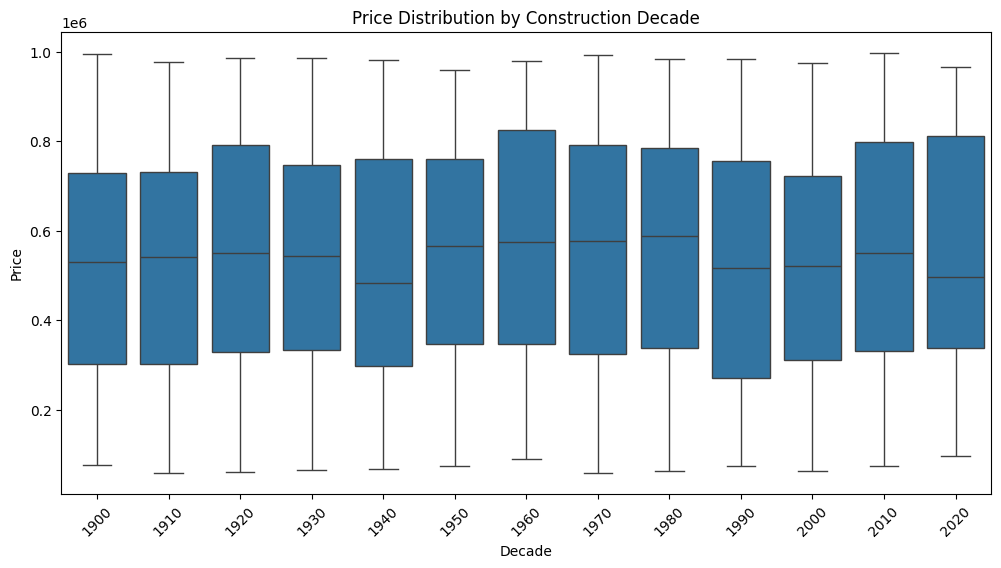

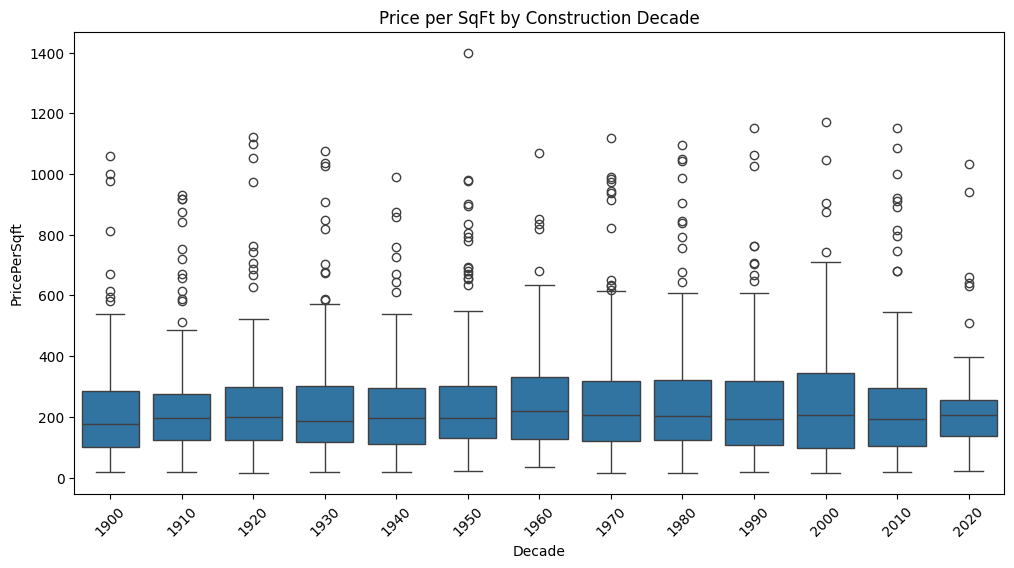


Location Distribution by Decade (%):
Location  Downtown  Rural  Suburban  Urban
Decade                                    
1900          22.1   24.3      27.2   26.5
1910          26.4   27.0      24.3   22.3
1920          20.4   27.4      26.1   26.1
1930          27.5   19.6      25.5   27.5
1940          34.1   19.7      21.2   25.0
1950          22.6   22.6      28.1   26.7
1960          28.6   23.0      24.6   23.8
1970          29.5   26.9      21.2   22.4
1980          32.1   21.4      23.6   22.9
1990          26.8   26.1      18.3   28.9
2000          27.3   21.8      28.5   22.4
2010          33.3   29.2      23.6   13.9
2020          29.1   18.2      27.3   25.5


In [37]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('../data/clean_house_data.csv')

# Create decade column
df['Decade'] = (df['YearBuilt'] // 10) * 10

# Basic decade stats
decade_stats = df.groupby('Decade').agg({
    'Price': ['count', 'mean', 'std', 'median'],
    'Area': 'mean',
    'Bedrooms': 'mean',
    'Bathrooms': 'mean'
}).round(2)

print("Decade Statistics:")
print(decade_stats)

# Visualize price distribution by decade
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Decade', y='Price')
plt.title('Price Distribution by Construction Decade')
plt.xticks(rotation=45)
plt.show()

# Price per sqft by decade
df['PricePerSqft'] = df['Price'] / df['Area']
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Decade', y='PricePerSqft')
plt.title('Price per SqFt by Construction Decade')
plt.xticks(rotation=45)
plt.show()

# Location distribution by decade
decade_location = pd.crosstab(df['Decade'], df['Location'], normalize='index')
print("\nLocation Distribution by Decade (%):")
print(decade_location.round(3) * 100)